# 05 - Comparison: baselines vs BiLSTM vs Transformer
Reads the shared outputs (`reports/results.csv`, `reports/predictions/`, `reports/experiment_log.csv`); trains nothing and runs in seconds. Run it after notebooks 02-04. Model 5 (BERTweet) appears automatically once its results are saved.

In [1]:
import os, sys

if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/formative2-vaccine-sentiment"
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(BASE)
sys.path.insert(0, BASE)

import json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from src.nn_utils import slice_report

sns.set_theme(style="whitegrid")
FIG = "reports/figures/"
ORDER = ["tfidf_logreg", "tfidf_ridge", "fasttext", "bilstm_glove", "transformer_scratch", "bertweet"]

## Test results (each model evaluated once)

,rmse,macro_f1,accuracy,weighted_f1,f1_negative,f1_neutral,f1_positive
model,,,,,,,
tfidf_logreg,0.5838,0.6551,0.7183,0.7233,0.4638,0.7916,0.7098
tfidf_ridge,0.5844,0.5139,0.6444,0.6188,0.2162,0.7091,0.6163
fasttext,0.6161,0.6048,0.7127,0.7026,0.3262,0.7833,0.7048
bilstm_glove,0.5977,0.6505,0.7357,0.7335,0.4130,0.7979,0.7404
transformer_scratch,0.6029,0.6542,0.7162,0.7259,0.4514,0.7897,0.7215


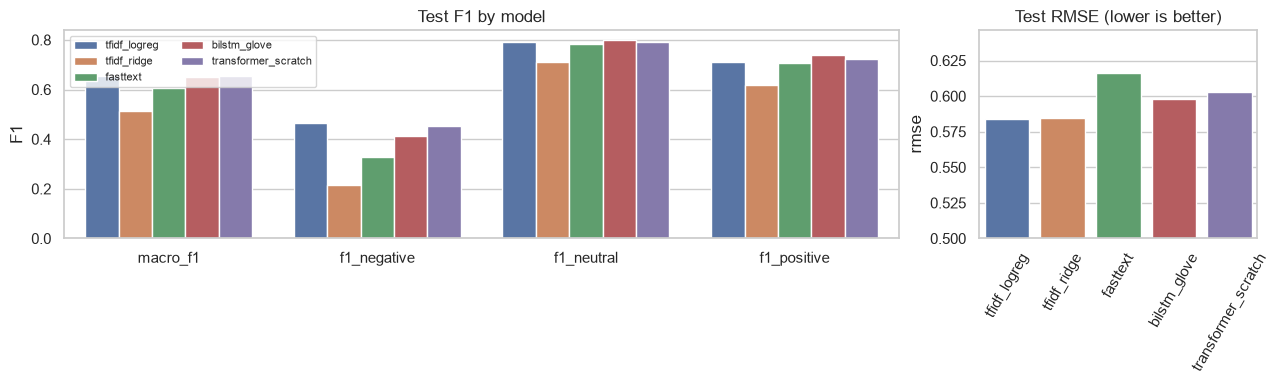

In [2]:
res = pd.read_csv("reports/results.csv")
models = [m for m in ORDER if m in set(res["model"])] + [m for m in res["model"] if m not in ORDER]
res = res.set_index("model").loc[models]
display(res.round(4))

long = res.reset_index().melt(id_vars="model", value_vars=["macro_f1", "f1_negative", "f1_neutral", "f1_positive"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [3, 1]})
sns.barplot(data=long, x="variable", y="value", hue="model", hue_order=models, ax=axes[0])
axes[0].set_title("Test F1 by model"); axes[0].set_xlabel(""); axes[0].set_ylabel("F1")
axes[0].legend(fontsize=8, ncol=2)
sns.barplot(x=res.index, y=res["rmse"], hue=res.index, hue_order=models, ax=axes[1], legend=False)
axes[1].set_title("Test RMSE (lower is better)"); axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=60)
axes[1].set_ylim(0.5, res["rmse"].max() + 0.03)
plt.tight_layout(); plt.savefig(FIG + "model_comparison.png", dpi=200); plt.show()

## Slices: negation (word order) and annotator agreement (label noise)

In [3]:
preds = [m for m in models if os.path.exists(f"reports/predictions/{m}.csv")]
display(slice_report(preds).round(3))

model,tfidf_logreg,tfidf_ridge,fasttext,bilstm_glove,transformer_scratch
slice,,,,,
agreement < 0.7 (n=583),0.556,0.422,0.485,0.517,0.541
agreement >= 0.7 (n=851),0.704,0.580,0.687,0.755,0.719
all (n=1434),0.655,0.514,0.605,0.650,0.654
no negation (n=1068),0.662,0.529,0.619,0.659,0.662
with negation (n=366),0.613,0.454,0.546,0.604,0.614


## Validation stability of the neural models (mean ± std over 3 seeds, final config)

In [4]:
log = pd.read_csv("reports/experiment_log.csv")
rows = []
for m in ["bilstm_glove", "transformer_scratch"]:
    sub = log[log["model"] == m].copy()
    if sub.empty:
        continue
    params = sub["params"].map(json.loads)
    cfg = params.map(lambda p: json.dumps({k: v for k, v in p.items() if k not in ("exp", "seed", "best_epoch")}, sort_keys=True))
    stats = sub.groupby(cfg)["val_macro_f1"].agg(["mean", "std", "count"])
    best_cfg = stats["mean"].idxmax()
    rows.append(dict(model=m, runs_logged=len(sub), configs=len(stats),
                     val_macro_f1_mean=stats.loc[best_cfg, "mean"], val_macro_f1_std=stats.loc[best_cfg, "std"],
                     config=best_cfg))
display(pd.DataFrame(rows).round(4))

,model,runs_logged,configs,val_macro_f1_mean,val_macro_f1_std,config
0,bilstm_glove,45,15,0.6563,0.0032,"{""bidirectional"": true, ""dim"": 100, ""dropout"":..."
1,transformer_scratch,36,12,0.6250,0.0035,"{""d_model"": 100, ""dropout"": 0.2, ""emb"": ""glove..."


## Summary
- **No sequential model beats the bag-of-n-grams baseline.** TF-IDF + Logistic Regression (0.655), the Transformer (0.654) and the BiLSTM (0.650) are within 0.005 test macro-F1 of each other. That is about the size of the seed std of the final neural configs (0.003-0.004) and far below the seed std of some other configs (up to 0.03). Logistic Regression has the best RMSE (0.584) and negative F1 (0.464); the BiLSTM has the best accuracy (0.736) and the best neutral and positive F1.
- **fastText and Ridge are clearly behind** (0.605 and 0.514), mainly on the negative class (F1 0.326 and 0.216).
- **Negative tweets are the hardest class for every model** (F1 0.22-0.46, against 0.71-0.80 for neutral and 0.62-0.74 for positive). Negative recall follows class weighting: the weighted models (Transformer 0.57, Logistic Regression 0.53) find more negative tweets than the unweighted ones (BiLSTM 0.38, fastText 0.25).
- **Negation:** every model loses 0.05-0.08 macro-F1 on tweets with negation, and the sequential models lose as much as the bag-of-words ones (BiLSTM 0.604, Transformer 0.614, Logistic Regression 0.613). The Transformer's final config uses no positional encoding at all (T1).
- **Label noise:** every model loses 0.15-0.24 macro-F1 on tweets with annotator agreement below 0.7. The BiLSTM gains the most on the clearly labelled tweets (0.755) and loses the most on the disputed ones (0.517).
- **What helped:** pretrained embeddings were the only clear gain in both neural models (L1 +0.035, T4 +0.030). This points to a model pretrained end-to-end on tweets (BERTweet, Model 5) as the next step, and to label noise as the ceiling that it will also face.